# AA_Cam_pose_sweeps

Sweeps camera density (target frame count, `cam_poses`) at a fixed video range (`start_3D_recon`..`end_3D_recon`) through every reconstruction technique, scores each against GPS ground truth, and pools everything into one CSV.

Process code (scoring, resumability/status tracking, disk-retention cleanup, the sweep loop itself) lives in `AA_cam_pose_sweeps.py`, next to this notebook -- import it, don't copy it, so fixes/improvements there apply to every per-case copy of this notebook automatically. This notebook only holds what varies per case:
- **Config**: `case_name`, frame range, `CAM_POSES`, `TECHNIQUE_ORDER`, `FLAGS`, and `DATA_STORAGE` (what to keep on disk afterwards vs delete).
- **Part 2 (Sweep)** is expensive (minutes per technique per density) and resumable -- safe to interrupt/kill and re-run from the top. GPU OOM kills the whole kernel outright (not a catchable Python exception), so the resumability design is disk-based, not in-process -- see `AA_cam_pose_sweeps.py`'s Resumability infrastructure section.
- **Part 3 (Load + plot)** is cheap -- it only reads the pooled CSV off disk, so the chart can be restyled/re-run any number of times without re-touching the sweep. Stays notebook-side since it's meant to be freely tweaked per case.

`align_and_score` and the trace loaders are reused from `F_post_recon_processing.py`/`AA_cam_pose_sweeps.py`, same functions `AA_Cam_pose_estimate_batches.ipynb` uses.

In [2]:
%load_ext autoreload
%autoreload 2

## Config

In [1]:
import sys
from pathlib import Path

# Find the repo root by walking up until we hit src/A_Config.py -- see
# AA_Cam_pose_estimate_batches.ipynb for why this is more robust than Path.cwd().parent.
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
sys.path.insert(0, str(project_root / "Experiments" / "templates"))
print("project_root:", project_root)

from A_Config import set_case, case_dir
from Two2D.B_video_processing import video_fps
from templates.AA_cam_pose_sweeps import reset_sweep_state, run_density_sweep

case_name = "12_walk_home_2"
experiment = "Cam_pose_v1"
set_case(case_name, experiment)  # must happen before any case_dir()/A_Config getter call below

source_dir   = case_dir() / "010_source"
videos = list(source_dir.glob("*.mp4"))
video_path = videos[0]


# Fixed video range -- only the frame DENSITY within this range varies across the sweep.
# Hardcoded per AI_coppertest3_vggt.ipynb's precedent (no reusable start/end-frame config exists yet).
start_3D_recon = 0
end_3D_recon = 23254


fps = video_fps(video_path)
print(f"video fps: {fps:.3f}")
import cv2; total_frames = int(cv2.VideoCapture(str(video_path)).get(cv2.CAP_PROP_FRAME_COUNT))
print("total_frames",total_frames )
# Target frame counts to sweep, ascending -- ascending order matters for the
# OOM-precaution logic in run_density_sweep (more frames -> more GPU memory).
CAM_POSES = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250,275,300]

# Fixed run order (user-specified) -- cheapest/most-reliable techniques first.
TECHNIQUE_ORDER = ["CUT3R","CUT3R_Revisit", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]

# Which techniques are actually enabled -- same defaults as AA_Cam_pose_estimate_batches.ipynb.
FLAGS = {
    "CUT3R":       False,
    "CUT3R_Revisit": False,
    "lingbot-map": False,
    "VGGT-Omega":  True,
    "MegaSaM":     False,
    "VGGT":        False,
}

# What the sweep keeps on disk afterwards vs deletes -- see AA_cam_pose_sweeps.py's
# _cleanup_technique_output for exactly what each toggle controls.
DATA_STORAGE = {
    "keep_inputs":     True,  # extracted frames per density (020_frames_for_cam_poses)
    "keep_recon_data": True,  # full heavy technique output (images/depth/point-clouds/caches)
    "keep_cam_poses":  True,   # lightweight <technique_output>/CAM_poses/poses.csv per density
    "full_pose":       True,  # rotation too, not just translation, in the retained CSV
    "render_bev":      True,   # one <technique_output>/BEV/bev.png per technique/density --
                                # every technique gets a Reconstruction (natively for VGGT-Omega,
                                # via F_transpose_to_recon_objects.py adapters for the rest), then
                                # P_projection_mapping.BEV_tile_render_PM renders from it. Cheap
                                # to keep even when keep_recon_data=False.
}
out_dir = case_dir() / "080_Experiments"
out_dir.mkdir(parents=True, exist_ok=True)

project_root: /workspace/project
video fps: 30.000
total_frames 27265


/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Reset sweep state

Deletes **only** this sweep's own output -- everything from running this sweep, nothing more, nothing less: every `poses_*` frame/reconstruction folder under the `experiment` tag defined above, plus the status/results CSVs. Nothing from `AA_Cam_pose_estimate_batches.ipynb` (different experiment name) or anything else in the case directory is touched.

Safe by default: with `CONFIRM_DELETE = False` this only prints what it *would* delete. Flip it to `True` and re-run the cell to actually delete.

In [5]:
CONFIRM_DELETE = False  # flip to True and re-run this cell to actually delete

reset_sweep_state(case_name, experiment, confirm=CONFIRM_DELETE)

confirm=False -- dry run only, nothing deleted. Would remove:
  (nothing to delete)


In [6]:
(end_3D_recon - start_3D_recon)

23254

## Ground truth

Same manual GT loading as `AA_Cam_pose_estimate_batches.ipynb` -- see that notebook for the naming-convention caveat.

In [9]:
from Q_GPS_processing import csv_to_GPS_dict

gt_csv_path = case_dir() / "000_GPS_Data" / "GPS_tags.csv"
GPS_dict = csv_to_GPS_dict(gt_csv_path)
print(f"{len(GPS_dict)} GT anchors loaded from {gt_csv_path.name}")

122 GT anchors loaded from GPS_tags.csv


## Part 2 -- Sweep (expensive, resumable, run once/rarely)

`run_density_sweep` (in `AA_cam_pose_sweeps.py`) gives each `cam_poses` value its own frames/output folders via a nested experiment tag (`f"{experiment}/poses_{cam_poses:04d}"` passed to `set_case`) -- this makes every `A_Config` getter (including `run_lingbot_map`'s, which has no path parameters at all and only reads the zero-arg getters) automatically density-scoped, with no per-function path-wrangling needed.

Safe to interrupt/kill and re-run from the top at any point.

In [10]:
run_density_sweep(
    case_name, experiment, video_path, start_3D_recon, end_3D_recon,
    CAM_POSES, TECHNIQUE_ORDER, FLAGS, DATA_STORAGE, project_root, GPS_dict,
)

Window  : clamped from ±465.5 to ±433 (half interval)
Video   : VID_20260812_155459131.mp4
          27.9 fps · 27265 frames · 975.9s
Range   : frames 0-23254 (23254 frames)
Sampling: every 867 frames (31.033333333333335s) → 27 candidates
Window  : ±433 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 23254/23254 [01:26<00:00, 269.42fr/s]


Selected: 27 frames  (26 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 23254/23254 [00:37<00:00, 626.40fr/s]


Log     : /workspace/project/Data/12_walk_home_2/020_frames_for_cam_poses/Cam_pose_v1/poses_0025/selection_log.json
Sharpness (at 25% res): min 3319 · mean 6057 · max 11491
27 frames  →  /workspace/project/Data/12_walk_home_2/035_VGGT_O_output/Cam_pose_v1/poses_0025
GPU freed -- 0.01 GiB still allocated, 0.02 GiB reserved
Saved: /workspace/project/Data/12_walk_home_2/035_VGGT_O_output/Cam_pose_v1/poses_0025/predictions.npz
Saved: /workspace/project/Data/12_walk_home_2/035_VGGT_O_output/Cam_pose_v1/poses_0025/scene.glb
min depth tensor(0.0012, device='cuda:0')
torch.Size([7133183, 3])
mins, maxes and ranges -0.03831857899203897 0.6081595224328339 0.6464781014248728 -0.006994375423528255 0.2744667818071321 0.28146115723066034
scale - original 6261.170628940968
min depth tensor(0.0012, device='cuda:0')
torch.Size([6776524, 3])
mins, maxes and ranges -0.03293428011238575 0.5000646952539682 0.532998975366354 -0.006096609518863261 0.2556136978091672 0.26171030732803047
scale - original 6969.

...

Log     : /workspace/project/Data/12_walk_home_2/020_frames_for_cam_poses/Cam_pose_v1/poses_0275/selection_log.json
Sharpness (at 25% res): min 82 · mean 4083 · max 12319
[VGGT-Omega @ 275] already failed (skipped_precautionary), skipping
Window  : clamped from ±39.0 to ±36 (half interval)
Video   : VID_20260812_155459131.mp4
          27.9 fps · 27265 frames · 975.9s
Range   : frames 0-23254 (23254 frames)
Sampling: every 73 frames (2.6s) → 319 candidates
Window  : ±36 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 23254/23254 [01:24<00:00, 274.16fr/s]


Selected: 319 frames  (212 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 23254/23254 [00:39<00:00, 581.52fr/s]

Log     : /workspace/project/Data/12_walk_home_2/020_frames_for_cam_poses/Cam_pose_v1/poses_0300/selection_log.json
Sharpness (at 25% res): min 82 · mean 4058 · max 11566
[VGGT-Omega @ 300] already failed (skipped_precautionary), skipping


## Part 3 -- Load + plot (cheap, re-runnable independently)

Reads `density_sweep_results.csv` fresh from disk -- does not depend on Part 2 having just run, so this cell can be re-run/restyled any number of times without touching the sweep. Colour mapping matches the informal `tab10`-by-insertion-order precedent in `AA_CAM_POSE_COMPARE_01.ipynb` cell 25 (`lingbot_map`, `VGGT_O`, `CUT3R`, `MegaSaM` kept at their original slots; `VGGT` plain wasn't in that precedent, so it reuses the freed `Reality_Scan` slot).

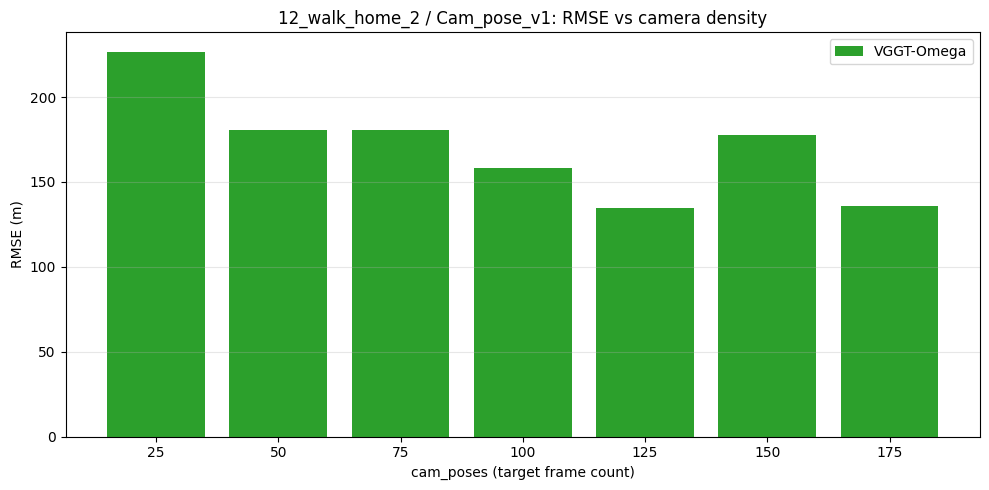

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
from A_Config import set_case, case_dir


results_path = case_dir() / "080_Experiments" / f"{experiment}" /f"{experiment}_results.csv"

TECHNIQUE_ORDER = ["CUT3R", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],  # no precedent for plain VGGT -- reuses the freed Reality_Scan slot
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    "CUT3R_Revisit": tab10[5],  # no precedent either -- n
}

df = pd.read_csv(results_path)
techniques = [t for t in TECHNIQUE_ORDER if t in df["technique"].unique()]
cam_poses_vals = sorted(df["cam_poses"].unique())

x = np.arange(len(cam_poses_vals))
width = 0.8 / max(len(techniques), 1)

fig, ax = plt.subplots(figsize=(10, 5))
for i, technique in enumerate(techniques):
    sub = df[df["technique"] == technique].set_index("cam_poses")["rmse"]
    heights = [sub.get(cp, np.nan) for cp in cam_poses_vals]
    ax.bar(x + i * width - 0.4 + width / 2, heights, width, label=technique, color=COLOR_MAP.get(technique))

ax.set_xticks(x)
ax.set_xticklabels(cam_poses_vals)
ax.set_xlabel("cam_poses (target frame count)")
ax.set_ylabel("RMSE (m)")
ax.set_title(f"{case_name} / {experiment}: RMSE vs camera density")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / f"{case_name}_{experiment}_RMSE.svg", format="svg", bbox_inches="tight")

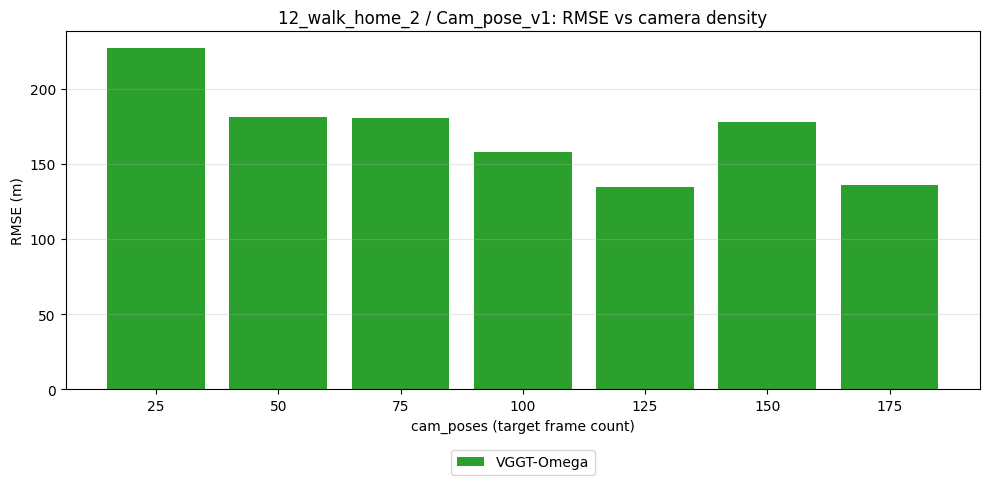

In [12]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
from A_Config import set_case, case_dir



set_case(case_name, experiment)
results_path = case_dir() / "080_Experiments" / f"{experiment}" / f"{experiment}_results.csv"

TECHNIQUE_ORDER = ["CUT3R", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],  # no precedent for plain VGGT -- reuses the freed Reality_Scan slot
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    
}

df = pd.read_csv(results_path)
techniques = [t for t in TECHNIQUE_ORDER if t in df["technique"].unique()]
cam_poses_vals = sorted(df["cam_poses"].unique())

x = np.arange(len(cam_poses_vals))
width = 0.8 / max(len(techniques), 1)

fig, ax = plt.subplots(figsize=(10, 5))
for i, technique in enumerate(techniques):
    sub = df[df["technique"] == technique].set_index("cam_poses")["rmse"]
    heights = [sub.get(cp, np.nan) for cp in cam_poses_vals]
    ax.bar(x + i * width - 0.4 + width / 2, heights, width, label=technique, color=COLOR_MAP.get(technique))

ax.set_xticks(x)
ax.set_xticklabels(cam_poses_vals)
ax.set_xlabel("cam_poses (target frame count)")
ax.set_ylabel("RMSE (m)")
ax.set_title(f"{case_name} / {experiment}: RMSE vs camera density")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / f"{case_name}_{experiment}_RMSE_nocut3rr.svg", format="svg", bbox_inches="tight")

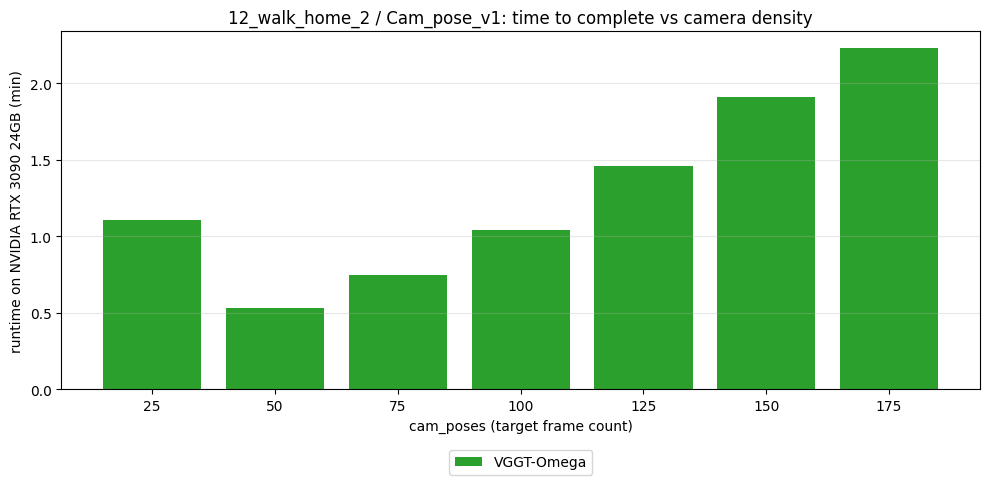

: 

In [ ]:
fig3, ax3 = plt.subplots(figsize=(10, 5))
for i, technique in enumerate(techniques):
    sub = df[df["technique"] == technique].set_index("cam_poses")["runtime (min)"]
    heights = [sub.get(cp, np.nan) for cp in cam_poses_vals]
    ax3.bar(x + i * width - 0.4 + width / 2, heights, width, label=technique, color=COLOR_MAP.get(technique))

ax3.set_xticks(x)
ax3.set_xticklabels(cam_poses_vals)
ax3.set_xlabel("cam_poses (target frame count)")
ax3.set_ylabel("runtime on NVIDIA RTX 3090 24GB (min)")
ax3.set_title(f"{case_name} / {experiment}: time to complete vs camera density")
ax3.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))
ax3.grid(axis="y", alpha=0.3)
fig3.tight_layout()
fig3.savefig(out_dir / f"{case_name}_{experiment}_runtime.svg", format="svg", bbox_inches="tight")